In [1]:
import zenidatasdk as zd
import alphalens
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time
import os

pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

# 检查版本
print(f"ZeniData SDK版本: {zd.__version__}")

# 测试导入主要模块
from zenidatasdk import Client
print("✅ 所有模块导入成功")

# 创建客户端（测试基础功能）
client = zd.Client()
print("✅ 客户端创建成功")

# 登录账号，初始化 client 对象
client = zd.Client(
    username = "3191883175@qq.com",
    password = "Abc123456", 
    base_url = "http://192.168.1.100:8000"
)
print("✅ 登录成功")

ZeniData SDK版本: 2.0.5
✅ 所有模块导入成功
✅ 客户端创建成功
✅ 登录成功


In [2]:
tmp_Dataset_path = rf"C:\Users\zy\Desktop\tmp_Dataset"          # 临时数据集路径
cutoff_date = rf"2026-04-10"                                    # 截至日期

cutoff_date_path = os.path.join(tmp_Dataset_path, cutoff_date)  # 临时数据集的 cutoff_date 路径
os.makedirs(cutoff_date_path, exist_ok = True)

In [3]:
symbols_df_path = os.path.join(cutoff_date_path, rf"symbols.csv")   # 定义截止日期的股票列表路径
if not os.path.exists(symbols_df_path):
    symbols_df = client.get_symbols_df(end_date = cutoff_date)      # 如果路径为空，获取截止日期的股票列表
    symbols_df.to_csv(symbols_df_path, index = False)               # 并保存

symbols_df = pd.read_csv(symbols_df_path)                           # 定义股票列表 DataFrame 对象
symbols_df.info()
print(symbols_df.head())
print(symbols_df.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   symbol       5494 non-null   object
 1   name         5494 non-null   object
 2   short_name   5494 non-null   object
 3   start_date   5494 non-null   object
 4   end_date     5494 non-null   object
 5   update_time  5494 non-null   object
dtypes: object(6)
memory usage: 257.7+ KB
        symbol   name short_name  start_date    end_date              update_time
0  000001.XSHE   平安银行       PAYH  1991-04-03  2200-01-01  2026-04-10 15:15:01.083
1  000002.XSHE    万科A        WKA  1991-01-29  2200-01-01  2026-04-10 15:15:01.083
2  000004.XSHE  *ST国华      *STGH  1990-12-01  2200-01-01  2026-04-10 15:15:01.083
3  000005.XSHE   ST星源       STXY  1990-12-10  2024-04-25  2026-04-10 15:15:01.083
4  000006.XSHE   深振业A       SZYA  1992-04-27  2200-01-01  2026-04-10 15:15:01.083
           symbol  name short_na

In [4]:
for index, item in symbols_df.iterrows():       # 遍历指定截止日期的 股票列表DataFrame
    symbol = item['symbol']                     # 赋值股票代码等变量
    name = item['name']
    short_name = item['short_name']
    start_date = item['start_date']
    end_date = item['end_date']
    # print(f"{index} {symbol} {name} {short_name}")
    
    bars_df_path = os.path.join(cutoff_date_path, rf"{symbol}.csv") # 定义指定股票的文件路径
    if not os.path.exists(bars_df_path):                            # 若路径为空
        bars_df = client.get_bars(                                  # 则获取股票 OHLCV数据
            symbol = symbol, 
            start_date = start_date, 
            end_date = cutoff_date, 
            frequency='1d', 
            adjust_type='post', 
            market='cn_stock'
        )
        bars_df.to_csv(bars_df_path, index = False)                 # 并写入指定路径

bars_df = pd.read_csv(bars_df_path)
bars_df.info()                  # 查看最后一个股票的结构
print(bars_df.head())           # 打印 DataFrame 的首尾
print(bars_df.tail())           # 用于 copy/paste 方便询问 ai

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1321 entries, 0 to 1320
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   open        1321 non-null   float64
 1   high        1321 non-null   float64
 2   low         1321 non-null   float64
 3   close       1321 non-null   float64
 4   pre_close   1321 non-null   float64
 5   high_limit  1321 non-null   float64
 6   low_limit   1321 non-null   float64
 7   avg         1321 non-null   float64
 8   volume      1321 non-null   float64
 9   datetime    1321 non-null   object 
 10  symbol      1321 non-null   object 
 11  amount      1321 non-null   float64
 12  paused      1321 non-null   float64
dtypes: float64(11), object(2)
memory usage: 134.3+ KB
    open   high    low  close  pre_close  high_limit  low_limit    avg      volume    datetime       symbol        amount  paused
0  33.00  49.80  33.00  38.50      18.94     10000.0       0.01  38.68  40954922.0  2020-10-2

In [6]:
# ==================== 2. 构建 Alphalens 格式的价格数据 ====================
import alphalens  # 或者 import alphalens as al，后面统一用 alphalens 即可

print(f"股票总数: {len(symbols_df)}")
print(f"分析截止日期: {cutoff_date}")

# 加载价格数据
price_dict = {}
valid_symbols = []

for symbol in symbols_df['symbol']:
    bars_df_path = os.path.join(cutoff_date_path, rf"{symbol}.csv")
    if os.path.exists(bars_df_path):
        try:
            df = pd.read_csv(bars_df_path, parse_dates=['datetime'])
            df = df.set_index('datetime').sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)  # 去除时区

            if 'close' in df.columns and df['close'].notna().sum() > 30:
                price_dict[symbol] = df['close']
                valid_symbols.append(symbol)
        except Exception as e:
            print(f"读取{symbol}出错: {e}")

# 合并价格面板
prices = pd.DataFrame(price_dict)
prices = prices.sort_index()
prices = prices.ffill(limit=3)  # 仅填充短期停牌

print(f"成功加载 {len(valid_symbols)} 只股票")
print(f"价格数据维度: {prices.shape}")

股票总数: 5494
分析截止日期: 2026-04-10
读取000765.XSHE出错: No columns to parse from file
读取600788.XSHG出错: No columns to parse from file
成功加载 5483 只股票
价格数据维度: (5164, 5483)


In [8]:
# ==================== 3. 计算动量因子（关键修复） ====================
print("\n=== 3. 计算动量因子并格式化 ===")

momentum_window = 20

# 计算动量因子（使用shift(1)避免未来数据泄漏）
factor_df = prices.pct_change(momentum_window).shift(1)

# 转换为 Long format（Alphalens标准格式：MultiIndex为(date, asset)）
factor_long = factor_df.stack().reset_index()
factor_long.columns = ['date', 'asset', 'factor']
factor_long = factor_long.dropna()

# 确保日期类型正确
factor_long['date'] = pd.to_datetime(factor_long['date'])

print(f"原始因子记录数: {len(factor_long)}")
print(f"因子日期范围: {factor_long['date'].min().date()} 至 {factor_long['date'].max().date()}")

# 关键修复：获取 factor 的实际日期范围
factor_min_date = factor_long['date'].min()
factor_max_date = factor_long['date'].max()

# ==================== 核心修复： prices 必须与 factor 对齐 ====================
# Alphalens 要求：
# 1. prices 必须包含 factor 的所有日期（用于对齐）
# 2. prices 必须延伸超过 factor 最大日期 max(periods) 天（用于计算 forward returns）

periods_list = [1, 5, 10]
max_period = max(periods_list)

# 截断 prices：保留 factor 日期范围 + 未来所需天数用于计算收益
# 同时保留 factor 日期之前的 prices 数据（用于对齐）
required_end_date = factor_max_date + pd.Timedelta(days=max_period + 5)  # +5天缓冲（考虑周末）

# 过滤 prices：从 factor 第一天开始，到 required_end_date 结束
# （保留 factor 第一天之前的 prices 数据是为了让 Alphalens 能找到对应日期）
prices_filtered = prices[(prices.index >= factor_min_date) & (prices.index <= required_end_date)]

print(f"过滤后价格日期范围: {prices_filtered.index.min().date()} 至 {prices_filtered.index.max().date()}")
print(f"价格波动矩阵形状: {prices_filtered.shape}")

# 创建 MultiIndex Factor（Alphalens标准格式）
factor = factor_long.set_index(['date', 'asset'])['factor']

# 检查数据质量
print(f"\n每日股票数量统计:")
daily_counts = factor.groupby(level=0).count()
print(daily_counts.describe())


=== 3. 计算动量因子并格式化 ===


C:\Users\zy\AppData\Local\Temp\ipykernel_15116\2968969444.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  factor_df = prices.pct_change(momentum_window).shift(1)


原始因子记录数: 16016419
因子日期范围: 2005-02-02 至 2026-04-10
过滤后价格日期范围: 2005-02-02 至 2026-04-10
价格波动矩阵形状: (5143, 5483)

每日股票数量统计:
count    5143.000000
mean     3114.217188
std      1351.721433
min      1345.000000
25%      1842.500000
50%      2843.000000
75%      4180.500000
max      5483.000000
Name: factor, dtype: float64


In [9]:
# ==================== 4. Alphalens 因子分析 ====================
print("\n=== 4. Alphalens 数据清洗与分析 ===")

# 使用 bins 替代 quantiles（当股票数量固定时更稳定）
# 或者使用 quantiles=5（如果每天股票数都是5492，quantiles=5没问题）

try:
    # 方案 A：先使用极高 max_loss 跑通，观察实际丢弃比例
    print("第一次尝试：使用宽松参数诊断...")
    clean_data = alphalens.utils.get_clean_factor_and_forward_returns(
        factor=factor,
        prices=prices_filtered,  # 使用过滤后的 prices
        periods=periods_list,
        quantiles=5,             # 每天5492只股票，分5组没问题
        bins=None,
        groupby=None,
        filter_zscore=None,      # 禁用 Z-score 过滤，保留更多数据
        max_loss=0.90,           # 临时放宽到90%，观察实际丢弃比例
        zero_aware=False
    )

    print(f"✅ 清洗成功！最终数据形状: {clean_data.shape}")
    print(f"数据预览:\n{clean_data.head()}")

    # 生成报告
    print("\n=== 5. 生成因子分析报告 ===")
    alphalens.tears.create_full_tear_sheet(
        clean_data,
        long_short=True,
        group_adjust=False,
        by_group=False
    )

except Exception as e:
    print(f"❌ 错误: {e}")
    print("\n=== 诊断信息 ===")

    # 详细诊断
    print(f"Factor index levels: {factor.index.names}")
    print(f"Factor 日期数量: {factor.index.get_level_values(0).nunique()}")
    print(f"Factor 股票数量: {factor.index.get_level_values(1).nunique()}")
    print(f"Prices 日期数量: {len(prices_filtered)}")
    print(f"Prices 股票数量: {len(prices_filtered.columns)}")

    # 检查重叠
    factor_dates = set(factor.index.get_level_values(0))
    price_dates = set(prices_filtered.index)
    common_dates = factor_dates & price_dates

    print(f"共同日期数量: {len(common_dates)}")
    print(f"只在 Factor 中的日期: {len(factor_dates - price_dates)}")
    print(f"只在 Prices 中的日期: {len(price_dates - factor_dates)}")

    # 如果还有问题，可能是股票代码不匹配
    factor_assets = set(factor.index.get_level_values(1))
    price_assets = set(prices_filtered.columns)
    print(f"Factor 股票代码数: {len(factor_assets)}")
    print(f"Prices 列名数: {len(price_assets)}")
    print(f"代码交集: {len(factor_assets & price_assets)}")
    print(f"只在 Factor 中的代码: {list(factor_assets - price_assets)[:5]}")
    print(f"只在 Prices 中的代码: {list(price_assets - factor_assets)[:5]}")


=== 4. Alphalens 数据清洗与分析 ===
第一次尝试：使用宽松参数诊断...


D:\anaconda3\envs\alphalens_env\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)


Dropped 0.3% entries from factor data: 0.3% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 90.0%, not exceeded: OK!
✅ 清洗成功！最终数据形状: (15961589, 5)
数据预览:
                              1D        5D       10D    factor  factor_quantile
date       asset                                                               
2005-02-02 000001.XSHE -0.014052  0.031259  0.037511 -0.065984                3
           000002.XSHE -0.010079 -0.010079 -0.008378  0.083494                5
           000004.XSHE -0.035196  0.001676  0.068715 -0.131318                1
           000005.XSHE -0.031548 -0.008804  0.036684 -0.009848                4
           000006.XSHE -0.004446  0.008892  0.067502 -0.009422                4

=== 5. 生成因子分析报告 ===
❌ 错误: create_full_tear_sheet() got an unexpected keyword argument 'group_adjust'

=== 诊断信息 ===
Factor index levels: ['date', 'asset']
Factor 日期数量: 5143
Factor 股票数量: 5483
Prices 日期数量: 5143

<Figure size 640x480 with 0 Axes>


=== 5. 生成因子分析报告 ===
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.968397,0.225160,-0.113806,0.095997,3226089,20.211578
2,-0.566105,0.340226,-0.042206,0.080466,3185599,19.957906
3,-0.506694,0.469871,-0.001491,0.081420,3195315,20.018778
4,-0.414059,0.648877,0.046021,0.085959,3189038,19.979452
5,-0.228599,26.625402,0.185508,0.228782,3165548,19.832286


Returns Analysis


,1D,5D,10D
Ann. alpha,-0.139,-0.122,-0.107
beta,-0.050,-0.048,-0.041
Mean Period Wise Return Top Quantile (bps),-9.031,-7.248,-6.145
Mean Period Wise Return Bottom Quantile (bps),2.990,2.577,2.423
Mean Period Wise Spread (bps),-12.021,-9.844,-8.589


<Figure size 640x480 with 0 Axes>

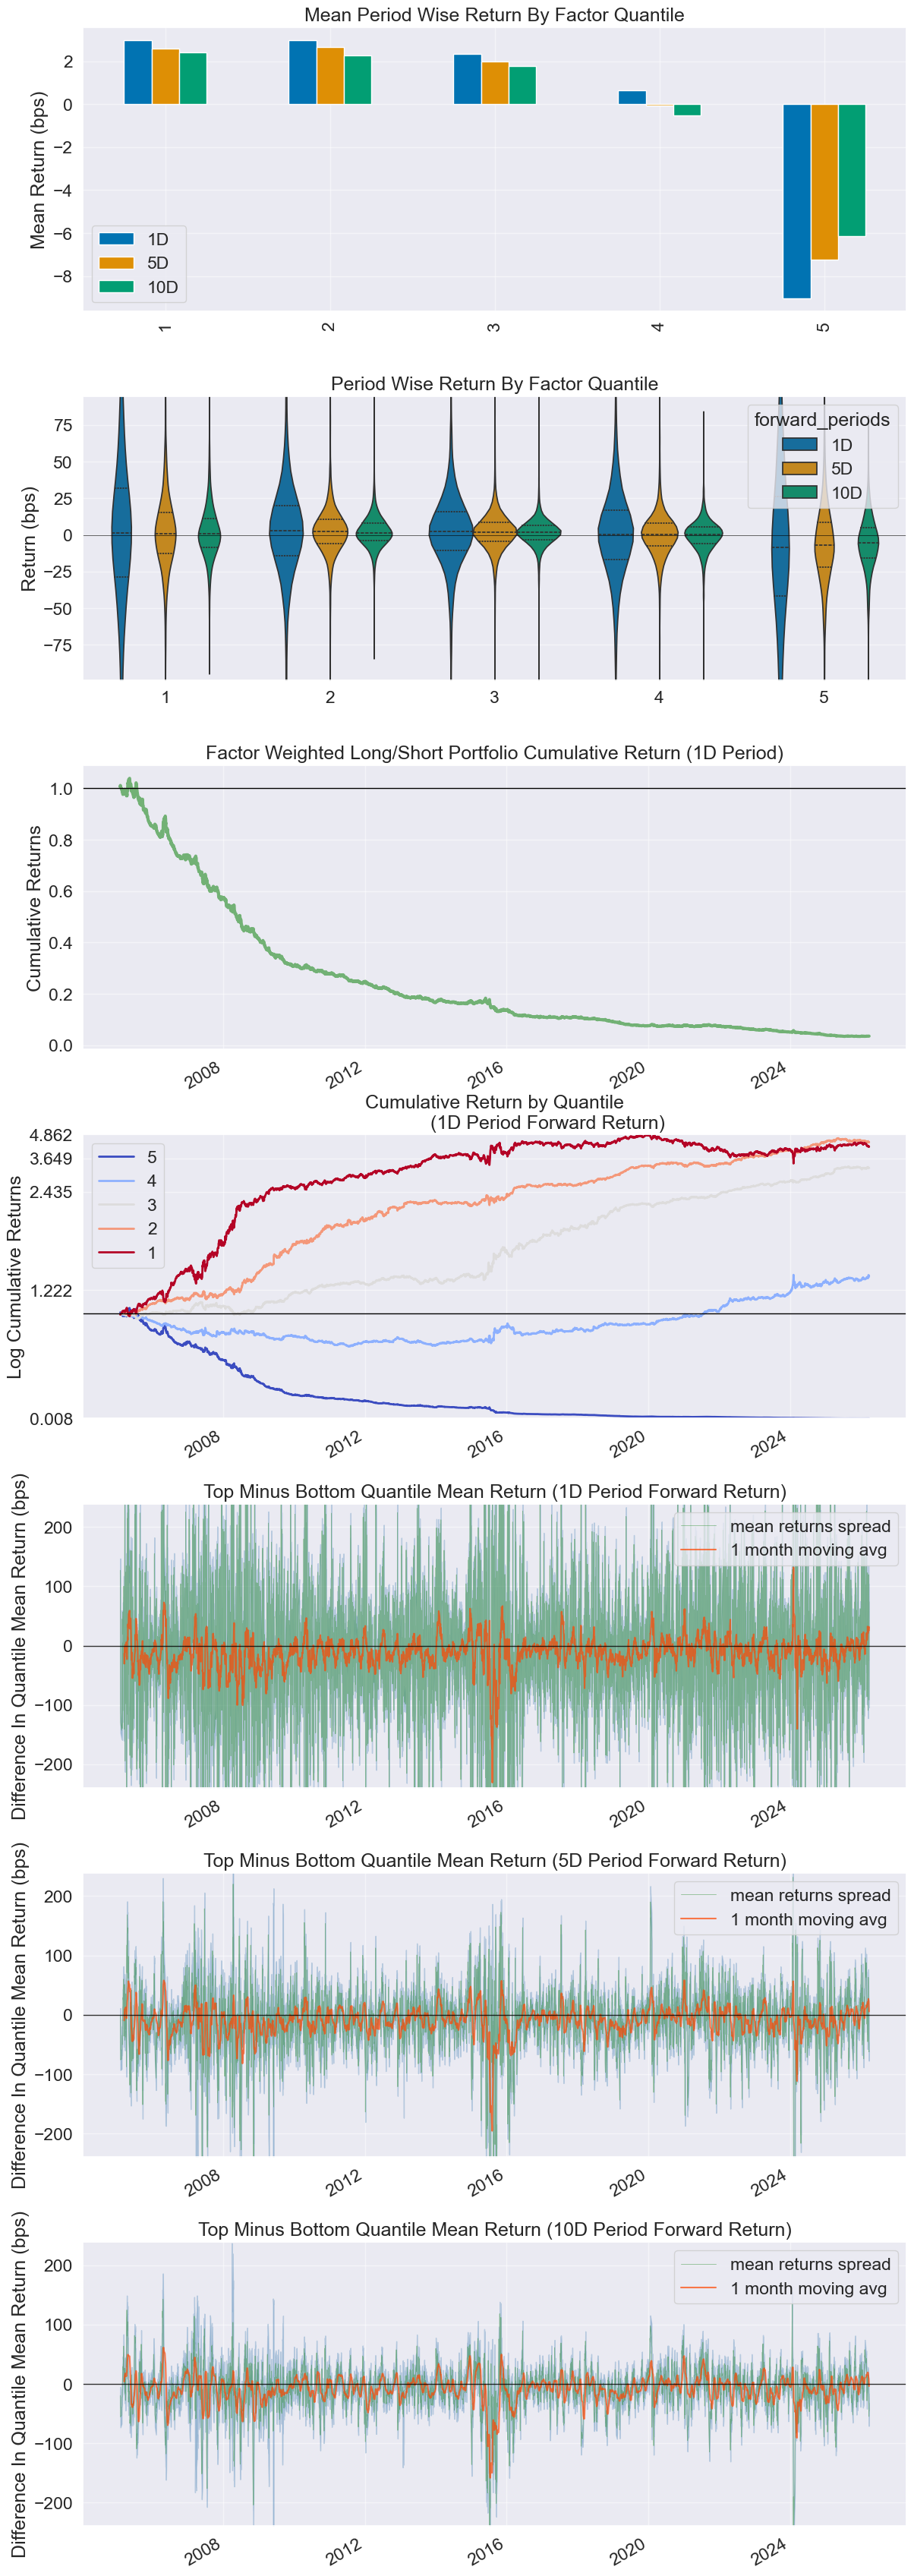

Information Analysis


,1D,5D,10D
IC Mean,-0.037,-0.051,-0.056
IC Std.,0.167,0.160,0.156
Risk-Adjusted IC,-0.224,-0.318,-0.361
t-stat(IC),-16.062,-22.781,-25.887
p-value(IC),0.000,0.000,0.000
IC Skew,-0.083,-0.273,-0.388
IC Kurtosis,0.324,0.621,0.649


D:\anaconda3\envs\alphalens_env\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


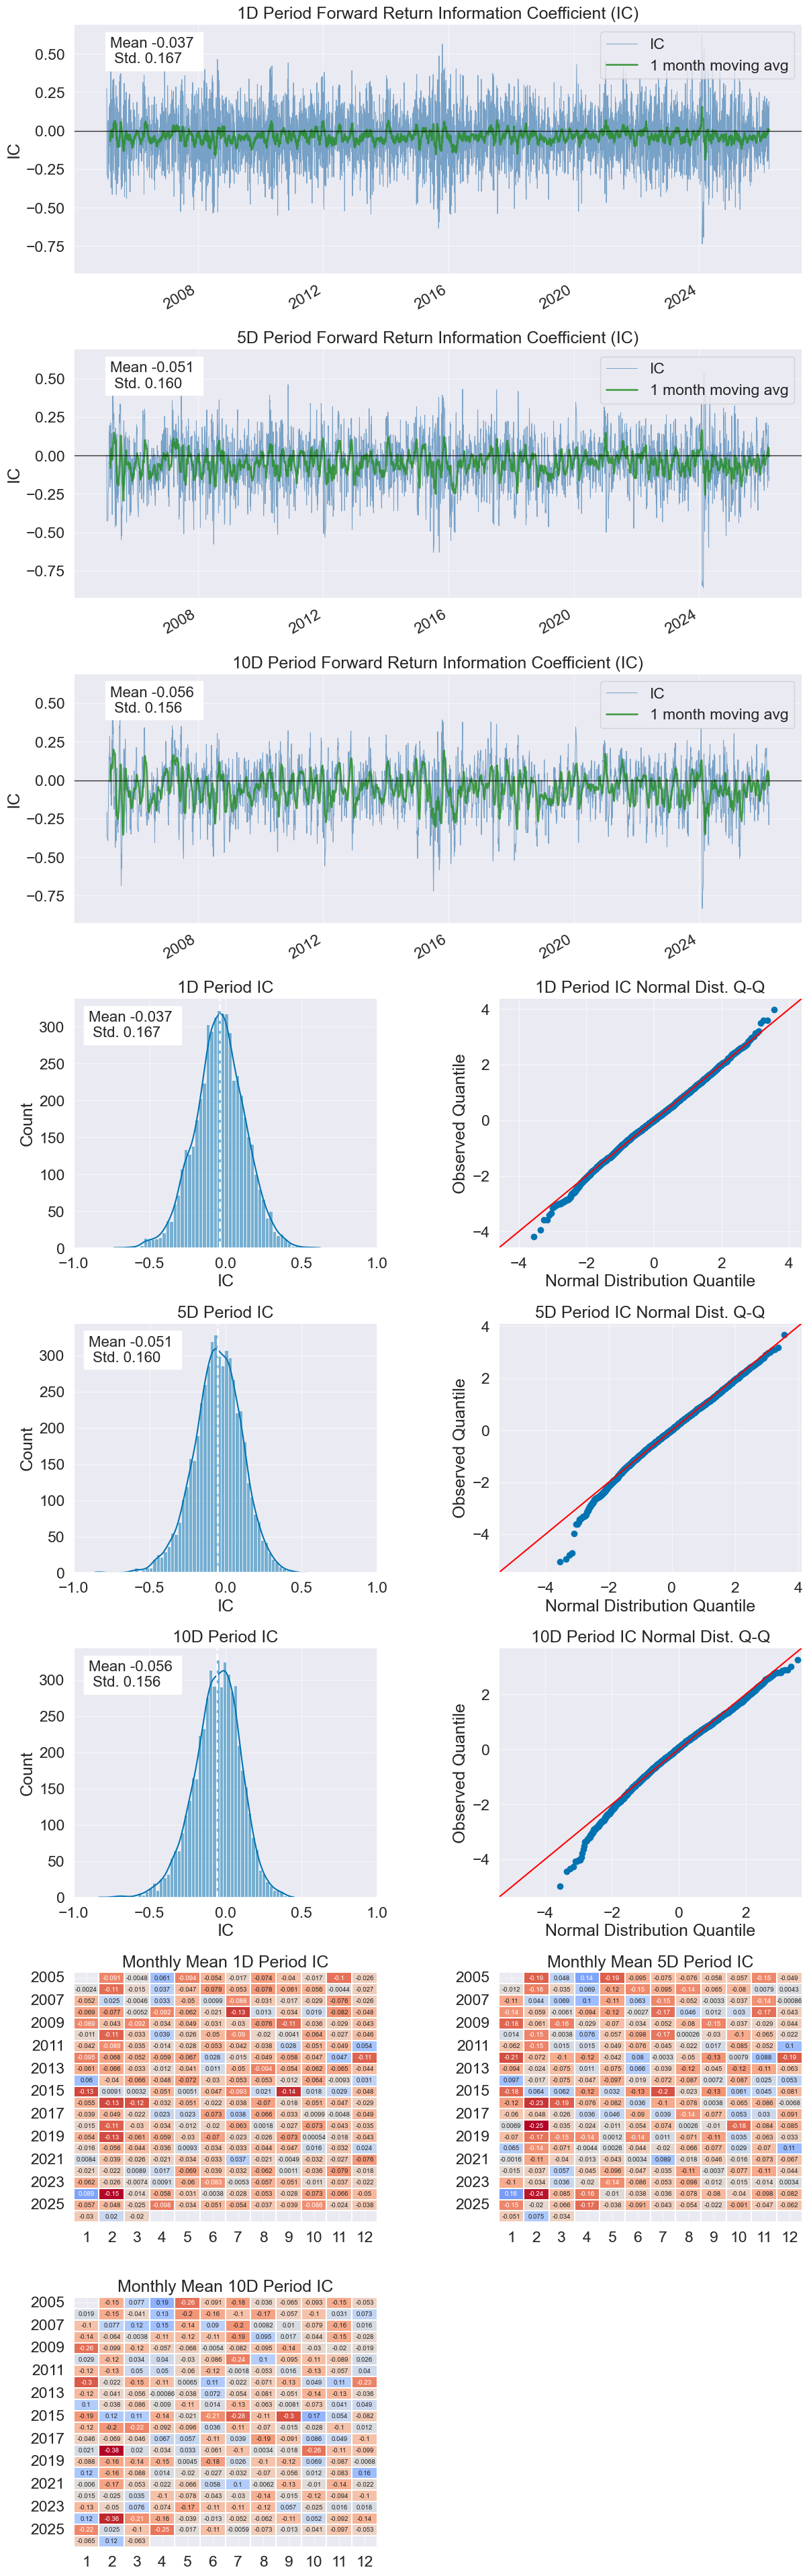

D:\anaconda3\envs\alphalens_env\Lib\site-packages\alphalens\utils.py:929: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.188,0.426,0.589
Quantile 2 Mean Turnover,0.397,0.643,0.725
Quantile 3 Mean Turnover,0.428,0.669,0.740
Quantile 4 Mean Turnover,0.371,0.634,0.726
Quantile 5 Mean Turnover,0.163,0.382,0.544


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.929,0.678,0.421


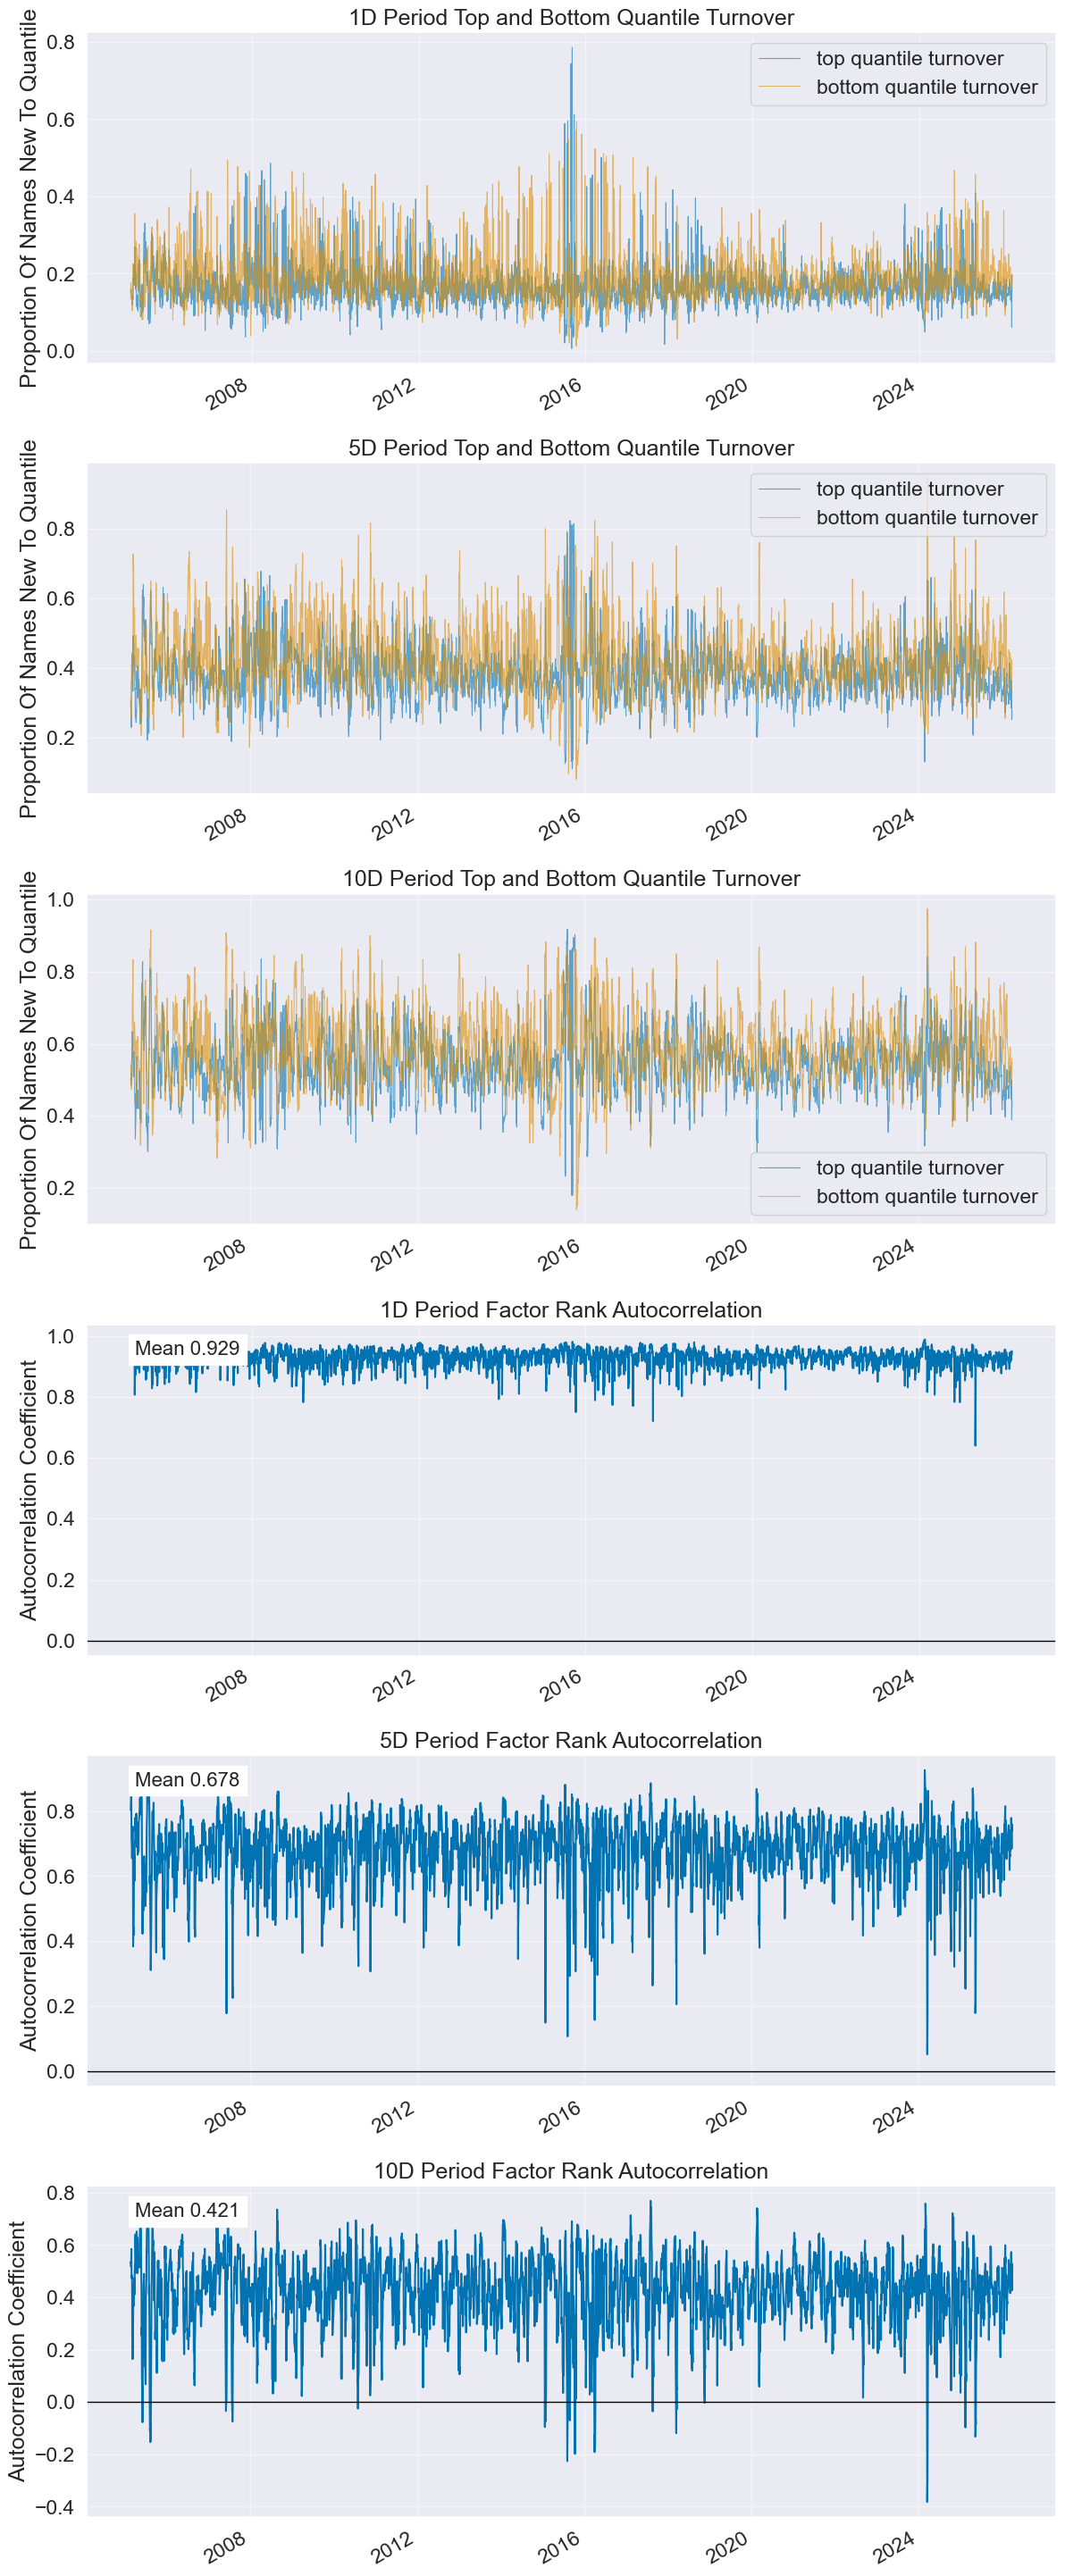


✅ 分析完成！


In [10]:
# ==================== 5. 生成因子分析报告 ====================
print("\n=== 5. 生成因子分析报告 ===")

# 修正参数名（根据你的 Alphalens 版本，可能是 group_neutral 或根本没有这个参数）
try:
    # 尝试新版参数名
    alphalens.tears.create_full_tear_sheet(
        clean_data,
        long_short=True,
        group_neutral=False,  # 替换 group_adjust
        by_group=False
    )
except TypeError as e:
    if "group_neutral" in str(e):
        # 如果 group_neutral 也不对，使用最小参数集
        print("尝试使用基础参数...")
        alphalens.tears.create_full_tear_sheet(
            clean_data,
            long_short=True,
            by_group=False
        )
    else:
        raise e

print("\n✅ 分析完成！")